# Fase 4 · Análisis y respuesta a la pregunta del proyecto

## MCDI500 · Grupo 7

Esta fase integra los resultados obtenidos en F1, F2 y F3 para responder la pregunta definida al inicio del proyecto:

**¿Cómo se distribuyen los montos netos de las órdenes de Compra Ágil de la unidad de Abastecimiento de la Municipalidad de Valparaíso según proveedor, rubro y mes de envío, durante enero–junio de 2025?**

El análisis utiliza como medida monetaria `MontoNetoOC_CLP` y distingue entre el universo original de órdenes y las órdenes habilitadas para el análisis.

Se consideran como estados habilitados:

- `Aceptada`
- `Recepcion Conforme`

Las órdenes en otros estados se conservan para trazabilidad, pero no forman parte de los agregados monetarios principales.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# Localizar la raíz del proyecto desde F4/notebooks
ROOT = Path.cwd().parents[1]

print("Raíz del proyecto:", ROOT)
print("Existe proyecto.json:", (ROOT / "proyecto.json").exists())
print("Existe F2:", (ROOT / "F2").exists())
print("Existe F3:", (ROOT / "F3").exists())

Raíz del proyecto: C:\Users\jguai\Documents\proyecto-grupo7-mcdi500
Existe proyecto.json: True
Existe F2: True
Existe F3: True


In [2]:
# Configuración común de visualización

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

DESTACADO = "#AC212E"
NEUTRO = "#9FB6C8"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold"
})

print("Configuración visual cargada correctamente.")

Configuración visual cargada correctamente.


In [3]:
import sys

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from F2.src.preprocesamiento import ejecutar_pipeline

resultado = ejecutar_pipeline(ROOT)

ordenes = resultado["ordenes"]
relacion_rubros = resultado["relacion_rubros"]
metricas = resultado["metricas"]

print("Órdenes totales:", len(ordenes))
print("Órdenes habilitadas:", int(ordenes["estado_habilitado_descriptivo"].sum()))
print("Estados encontrados:")
print(ordenes["EstadoOC"].value_counts())
print("Relaciones OC-rubro:", len(relacion_rubros))
print("Órdenes no conciliadas:", metricas["ordenes_no_conciliadas"])

Órdenes totales: 541
Órdenes habilitadas: 540
Estados encontrados:
EstadoOC
Aceptada                    537
Recepcion Conforme            3
Solicitud de Cancelacion      1
Name: count, dtype: Int64
Relaciones OC-rubro: 1683
Órdenes no conciliadas: ['2427-264-AG25', '2427-511-AG25', '2427-543-AG25']


In [4]:
# Universo analítico principal: solo estados habilitados
ordenes_analisis = ordenes.loc[
    ordenes["estado_habilitado_descriptivo"]
].copy()

print("Órdenes totales:", len(ordenes))
print("Órdenes incluidas en análisis:", len(ordenes_analisis))
print("Órdenes excluidas:", len(ordenes) - len(ordenes_analisis))

print("\nEstados incluidos:")
print(ordenes_analisis["EstadoOC"].value_counts())

print("\nMonto neto total analizado:")
print(f"${ordenes_analisis['MontoNetoOC_CLP'].sum():,.0f} CLP")

Órdenes totales: 541
Órdenes incluidas en análisis: 540
Órdenes excluidas: 1

Estados incluidos:
EstadoOC
Aceptada              537
Recepcion Conforme      3
Name: count, dtype: Int64

Monto neto total analizado:
$667,785,115 CLP


In [5]:
# Distribución mensual de órdenes y montos

resumen_mes = (
    ordenes_analisis
    .groupby("mes_envio", as_index=False)
    .agg(
        ordenes=("codigoOC", "nunique"),
        monto_neto_total=("MontoNetoOC_CLP", "sum"),
        monto_neto_promedio=("MontoNetoOC_CLP", "mean")
    )
)

resumen_mes["participacion_pct"] = (
    resumen_mes["monto_neto_total"]
    / resumen_mes["monto_neto_total"].sum()
    * 100
)

resumen_mes["monto_neto_total"] = resumen_mes["monto_neto_total"].round(0)
resumen_mes["monto_neto_promedio"] = resumen_mes["monto_neto_promedio"].round(0)
resumen_mes["participacion_pct"] = resumen_mes["participacion_pct"].round(2)

resumen_mes

,mes_envio,ordenes,monto_neto_total,monto_neto_promedio,participacion_pct
0,2025-01,56,69577225.0,1242450.0,10.42
1,2025-02,77,118183917.0,1534856.0,17.7
2,2025-03,100,138321637.0,1383216.0,20.71
3,2025-04,96,112183971.0,1168583.0,16.8
4,2025-05,114,114467815.0,1004104.0,17.14
5,2025-06,97,115050552.0,1186088.0,17.23


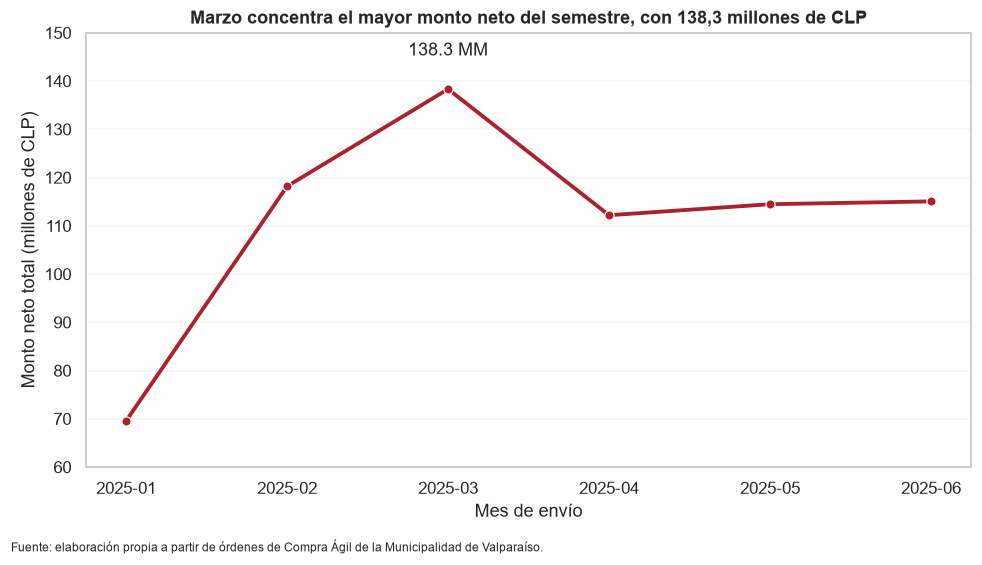

In [6]:
# Visualización 1: evolución mensual del monto neto

fig, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=resumen_mes,
    x="mes_envio",
    y="monto_neto_total",
    marker="o",
    linewidth=2.5,
    color=DESTACADO,
    ax=ax
)

# Identificar el mes con mayor monto neto
fila_max = resumen_mes.loc[
    resumen_mes["monto_neto_total"].idxmax()
]

# Anotar el valor máximo
ax.annotate(
    f"{fila_max['monto_neto_total'] / 1_000_000:.1f} MM",
    xy=(
        fila_max["mes_envio"],
        fila_max["monto_neto_total"]
    ),
    xytext=(0, 22),
    textcoords="offset points",
    ha="center",
    arrowprops=dict(arrowstyle="->")
)

# Título orientado al hallazgo
ax.set_title(
    "Marzo concentra el mayor monto neto del semestre, con 138,3 millones de CLP"
)

ax.set_xlabel("Mes de envío")
ax.set_ylabel("Monto neto total (millones de CLP)")

# Mostrar el eje Y directamente en millones
ticks = ax.get_yticks()
ax.set_yticks(ticks)
ax.set_yticklabels(
    [f"{valor / 1_000_000:.0f}" for valor in ticks]
)

# Economía visual
ax.grid(axis="y", alpha=0.2)
ax.grid(axis="x", visible=False)

# Fuente
fig.text(
    0.01,
    -0.02,
    "Fuente: elaboración propia a partir de órdenes de Compra Ágil de la Municipalidad de Valparaíso.",
    fontsize=8
)

plt.tight_layout()
plt.show()

### Interpretación

**Resultado observado.** Marzo presenta el mayor monto neto mensual del período analizado, con aproximadamente 138,3 millones de CLP, equivalente al 20,71% del total. Enero registra el menor monto, con cerca de 69,6 millones de CLP.

**Interpretación.** La evolución mensual muestra un aumento entre enero y marzo, seguido de una disminución en abril y una estabilización relativa entre abril y junio. La cantidad de órdenes no explica por sí sola el monto mensual, ya que mayo registra más órdenes que marzo, pero un monto acumulado menor.

**Límite.** El análisis describe montos netos asociados a órdenes de compra y no pagos efectivos ni ejecución presupuestaria. Además, el período observado corresponde únicamente a enero-junio de 2025, por lo que no permite inferir estacionalidad anual.

In [7]:
# Tabla resumen por proveedor

resumen_proveedor = (
    ordenes_analisis
    .groupby(
        ["ProveedorRUT_normalizado", "Proveedor"],
        as_index=False
    )
    .agg(
        ordenes=("codigoOC", "nunique"),
        monto_neto_total=("MontoNetoOC_CLP", "sum"),
        monto_neto_promedio=("MontoNetoOC_CLP", "mean")
    )
)

resumen_proveedor["participacion_pct"] = (
    resumen_proveedor["monto_neto_total"]
    / resumen_proveedor["monto_neto_total"].sum()
    * 100
)

resumen_proveedor = (
    resumen_proveedor
    .sort_values("monto_neto_total", ascending=False)
    .reset_index(drop=True)
)

resumen_proveedor["monto_neto_total"] = (
    resumen_proveedor["monto_neto_total"].round(0)
)

resumen_proveedor["monto_neto_promedio"] = (
    resumen_proveedor["monto_neto_promedio"].round(0)
)

resumen_proveedor["participacion_pct"] = (
    resumen_proveedor["participacion_pct"].round(2)
)

resumen_proveedor.head(10)

,ProveedorRUT_normalizado,Proveedor,ordenes,monto_neto_total,monto_neto_promedio,participacion_pct
0,77153112-1,4MED SPA,28,32756740.0,1169884.0,4.91
1,76096353-4,PRODUCTORA V12 MKT & PROMOCIONES & LOGISTICA L...,5,13716017.0,2743203.0,2.05
2,77787870-0,RENE GODOY Y COMPANIA LIMITADA,3,13354200.0,4451400.0,2.0
3,76583454-6,Venta y Reparación Erika Lucy Alfaro Carvacho ...,3,13120128.0,4373376.0,1.96
4,76307498-6,SOCIEDAD COMERCIAL HERMANOS BIJIT LIMITADA,3,12278400.0,4092800.0,1.84
5,77540301-2,SOCIEDAD COMERCIAL M&T SPA,3,10722588.0,3574196.0,1.61
6,77201245-4,FERREACEROS SPA,4,10543911.0,2635978.0,1.58
7,76467614-9,PATRICIA DEL LUJÁN GARRIDO PRODUCCIÓN EVENTOS ...,2,10142857.0,5071428.0,1.52
8,77426298-9,IMPRENTA FULL IMAGEN SPA,9,9857200.0,1095244.0,1.48
9,77591848-9,"BASUALTO Y TRIGO FARFAN, TRANSPORTE Y SERVICIO...",5,9735200.0,1947040.0,1.46


In [8]:
top10_participacion = resumen_proveedor.head(10)["participacion_pct"].sum()

print(f"Participación acumulada de los 10 principales proveedores: {top10_participacion:.2f}%")

Participación acumulada de los 10 principales proveedores: 20.41%


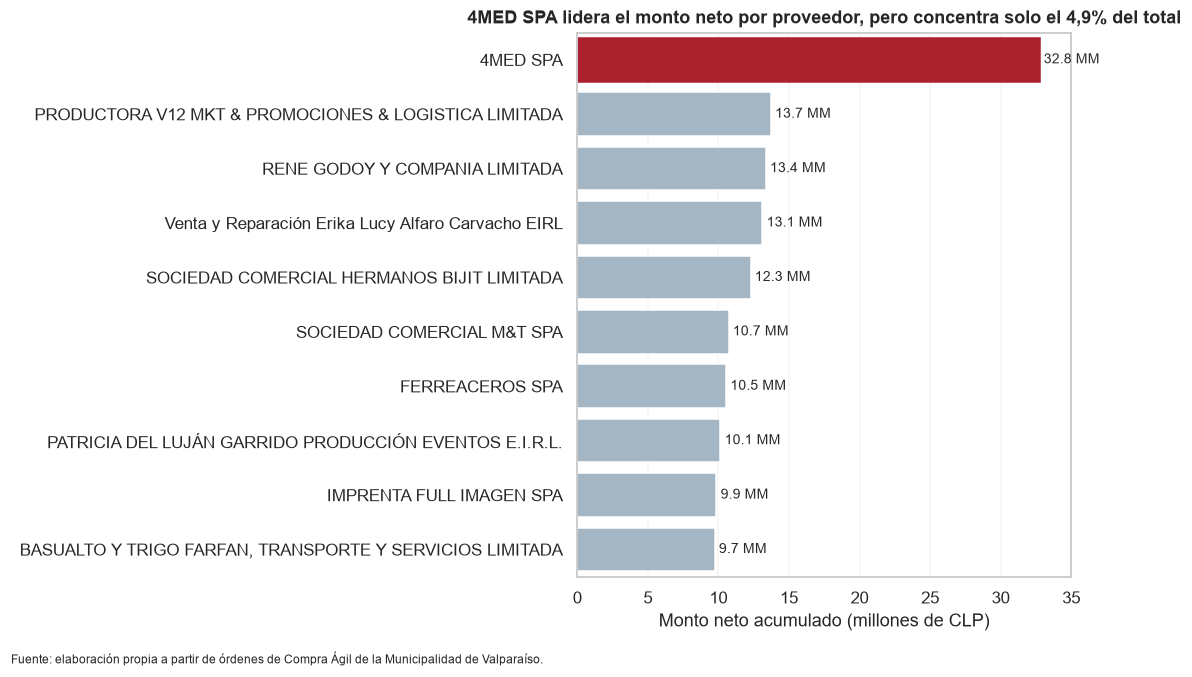

In [9]:
top10_proveedores = resumen_proveedor.head(10).copy()

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top10_proveedores,
    y="Proveedor",
    x="monto_neto_total",
    color=NEUTRO,
    ax=ax
)

# Destacar al proveedor con mayor monto
ax.patches[0].set_color(DESTACADO)

ax.set_title(
    "4MED SPA lidera el monto neto por proveedor, pero concentra solo el 4,9% del total",
    fontweight="bold"
)

ax.set_xlabel("Monto neto acumulado (millones de CLP)")
ax.set_ylabel("")

ticks = ax.get_xticks()
ax.set_xticks(ticks)
ax.set_xticklabels([f"{valor/1_000_000:.0f}" for valor in ticks])

for i, fila in top10_proveedores.iterrows():
    ax.text(
        fila["monto_neto_total"] + 300_000,
        i,
        f"{fila['monto_neto_total']/1_000_000:.1f} MM",
        va="center",
        fontsize=9
    )

ax.grid(axis="x", alpha=0.2)
ax.grid(axis="y", visible=False)

fig.text(
    0.01,
    -0.02,
    "Fuente: elaboración propia a partir de órdenes de Compra Ágil de la Municipalidad de Valparaíso.",
    fontsize=8
)

plt.tight_layout()
plt.show()

### Interpretación

**Resultado observado.** 4MED SPA presenta el mayor monto neto acumulado por proveedor, con aproximadamente 32,8 millones de CLP, equivalente al 4,91% del total analizado. Los diez principales proveedores concentran en conjunto el 20,41% del monto neto.

**Interpretación.** La participación del proveedor con mayor monto es relativamente baja respecto del total, y la concentración acumulada de los diez principales también es acotada. Esto evidencia que los montos se distribuyen entre un número amplio de proveedores, más que concentrarse en unos pocos actores.

**Límite.** El análisis utiliza montos netos asociados a órdenes de compra y no pagos efectivamente realizados. Por ello, los resultados no permiten evaluar desempeño de proveedores, causalidad en la adjudicación ni participación de oferentes que no resultaron seleccionados.

In [10]:
# Revisar las órdenes cuya conciliación de detalle no es exacta

codigos_no_conciliados = metricas["ordenes_no_conciliadas"]

revision_no_conciliadas = (
    ordenes.loc[
        ordenes["codigoOC"].isin(codigos_no_conciliados),
        [
            "codigoOC",
            "EstadoOC",
            "MontoNetoOC_CLP",
            "estado_habilitado_descriptivo"
        ]
    ]
    .sort_values("codigoOC")
)

revision_no_conciliadas

,codigoOC,EstadoOC,MontoNetoOC_CLP,estado_habilitado_descriptivo
137,2427-264-AG25,Aceptada,2000000.0,True
346,2427-511-AG25,Aceptada,37473.0,True
380,2427-543-AG25,Aceptada,1490341.0,True


In [11]:
# Construir base conciliada para análisis monetario por rubro

conciliacion = resultado["conciliacion"]

codigos_conciliados = conciliacion.loc[
    conciliacion["concilia_firmas_a_1_clp"],
    "codigoOC"
]

ordenes_rubro = ordenes_analisis.loc[
    ordenes_analisis["codigoOC"].isin(codigos_conciliados)
].copy()

print("Órdenes habilitadas:", len(ordenes_analisis))
print("Órdenes usadas para análisis por rubro:", len(ordenes_rubro))
print("Órdenes excluidas del análisis por rubro:", len(ordenes_analisis) - len(ordenes_rubro))

monto_rubro_base = ordenes_rubro["MontoNetoOC_CLP"].sum()
monto_total_analisis = ordenes_analisis["MontoNetoOC_CLP"].sum()

print(f"\nMonto cubierto por análisis de rubros: ${monto_rubro_base:,.0f} CLP")
print(f"Cobertura monetaria: {monto_rubro_base / monto_total_analisis * 100:.2f}%")

Órdenes habilitadas: 540
Órdenes usadas para análisis por rubro: 537
Órdenes excluidas del análisis por rubro: 3

Monto cubierto por análisis de rubros: $664,257,301 CLP
Cobertura monetaria: 99.47%


In [12]:
# Reconstrucción monetaria por RubroN1 desde el detalle conciliado

from F1.src.entorno import cargar_configuracion, reconocer_archivo
from F2.src.preprocesamiento import convertir_decimal

config = cargar_configuracion(ROOT)
datos_raw = reconocer_archivo(ROOT, config)

# Misma firma de ítem utilizada y validada previamente en F2
firma_item = ["codigoOC"] + config["seleccion"]["firma_item"]

items_rubro = (
    datos_raw[firma_item]
    .drop_duplicates()
    .copy()
)

items_rubro["MontoNetoItemCLP_num"] = convertir_decimal(
    items_rubro["MontoNetoItemCLP"]
)

# Solo OC habilitadas cuyo detalle concilia
items_rubro = items_rubro.loc[
    items_rubro["codigoOC"].isin(ordenes_rubro["codigoOC"])
].copy()

resumen_rubro = (
    items_rubro
    .groupby("RubroN1", as_index=False)
    .agg(
        ordenes=("codigoOC", "nunique"),
        monto_neto_total=("MontoNetoItemCLP_num", "sum")
    )
    .sort_values("monto_neto_total", ascending=False)
    .reset_index(drop=True)
)

resumen_rubro["participacion_pct"] = (
    resumen_rubro["monto_neto_total"]
    / resumen_rubro["monto_neto_total"].sum()
    * 100
)

# Verificación de consistencia monetaria
monto_reconstruido = resumen_rubro["monto_neto_total"].sum()

print(f"Monto base de OC conciliadas: ${monto_rubro_base:,.0f} CLP")
print(f"Monto reconstruido desde ítems: ${monto_reconstruido:,.0f} CLP")
print(f"Diferencia: ${monto_reconstruido - monto_rubro_base:,.2f} CLP")

resumen_rubro["monto_neto_total"] = resumen_rubro["monto_neto_total"].round(0)
resumen_rubro["participacion_pct"] = resumen_rubro["participacion_pct"].round(2)

resumen_rubro.head(10)

Monto base de OC conciliadas: $664,257,301 CLP
Monto reconstruido desde ítems: $664,257,301 CLP
Diferencia: $0.00 CLP


,RubroN1,ordenes,monto_neto_total,participacion_pct
0,"Servicios profesionales, administrativos y con...",22,61811345.0,9.31
1,"Tecnologías de la información, telecomunicacio...",47,49429159.0,7.44
2,"Artículos para estructuras, obras y construcci...",44,47597675.0,7.17
3,"Servicios editoriales, de diseño, publicidad, ...",36,46372060.0,6.98
4,Vehículos y equipamiento en general,21,40372019.0,6.08
5,"Equipos y suministros de defensa, orden públic...",27,27475795.0,4.14
6,Artículos de fabricación y producción,79,26809920.0,4.04
7,"Servicios de transporte, almacenaje y correo",17,23842000.0,3.59
8,Muebles y mobiliario,18,21893940.0,3.3
9,"Servicios de Viajes, alimentación, alojamiento...",22,20132204.0,3.03


In [13]:
# Composición del monto conciliado por rubro

top5_rubros = resumen_rubro.head(5).copy()

participacion_top5 = top5_rubros["participacion_pct"].sum()
participacion_otros = 100 - participacion_top5

print(f"Participación de los 5 principales rubros: {participacion_top5:.2f}%")
print(f"Participación del resto de los rubros: {participacion_otros:.2f}%")

Participación de los 5 principales rubros: 36.98%
Participación del resto de los rubros: 63.02%


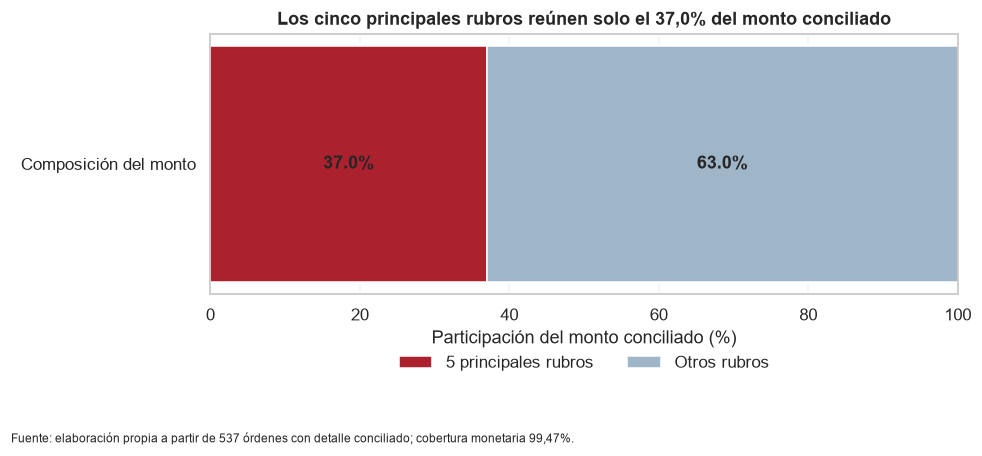

In [14]:
# Tercer gráfico: composición del monto conciliado por rubro

composicion_rubros = pd.DataFrame({
    "grupo": ["Composición del monto"],
    "5 principales rubros": [participacion_top5],
    "Otros rubros": [participacion_otros]
})

fig, ax = plt.subplots(figsize=(9, 3.8))

ax.barh(
    composicion_rubros["grupo"],
    composicion_rubros["5 principales rubros"],
    label="5 principales rubros",
    color=DESTACADO
)

ax.barh(
    composicion_rubros["grupo"],
    composicion_rubros["Otros rubros"],
    left=composicion_rubros["5 principales rubros"],
    label="Otros rubros",
    color=NEUTRO
)

ax.text(
    participacion_top5 / 2,
    0,
    f"{participacion_top5:.1f}%",
    ha="center",
    va="center",
    fontweight="bold"
)

ax.text(
    participacion_top5 + participacion_otros / 2,
    0,
    f"{participacion_otros:.1f}%",
    ha="center",
    va="center",
    fontweight="bold"
)

ax.set_xlim(0, 100)

ax.set_title(
    "Los cinco principales rubros reúnen solo el 37,0% del monto conciliado",
    fontweight="bold"
)

ax.set_xlabel("Participación del monto conciliado (%)")
ax.set_ylabel("")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False
)

ax.grid(axis="x", alpha=0.2)
ax.grid(axis="y", visible=False)

fig.text(
    0.01,
    -0.08,
    "Fuente: elaboración propia a partir de 537 órdenes con detalle conciliado; cobertura monetaria 99,47%.",
    fontsize=8
)

plt.tight_layout()
plt.show()

### Interpretación

**Resultado observado.** Los cinco rubros con mayor monto neto reúnen el 36,98% del monto conciliado, mientras que el 63,02% restante se distribuye entre los demás rubros.

**Interpretación.** La composición muestra que el monto no se concentra mayoritariamente en un pequeño grupo de rubros. Esto sugiere una distribución amplia entre distintos tipos de bienes y servicios dentro de las órdenes analizadas.

**Límite.** El análisis por rubro utiliza 537 órdenes cuyo detalle pudo conciliarse con la cabecera, equivalentes al 99,47% del monto neto habilitado. Tres órdenes quedaron fuera de esta desagregación por presentar diferencias de conciliación, aunque se conservaron y documentaron como excepciones.

## Respuesta integrada a la pregunta del proyecto

La pregunta planteada al inicio del proyecto fue:

**¿Cómo se distribuyen los montos netos de las órdenes de Compra Ágil de la unidad de Abastecimiento de la Municipalidad de Valparaíso según proveedor, rubro y mes de envío, durante enero-junio de 2025?**

El análisis de las 540 órdenes habilitadas muestra que el monto neto total considerado alcanza aproximadamente **667,8 millones de CLP**.

En la dimensión temporal, **marzo registra el mayor monto neto mensual**, con aproximadamente **138,3 millones de CLP**, equivalentes al **20,71%** del total analizado. Enero presenta el menor monto del período, mientras que entre abril y junio los montos permanecen relativamente estables. La cantidad de órdenes y el monto mensual no siguen necesariamente el mismo patrón, ya que mayo presenta la mayor cantidad de órdenes, pero no el mayor monto acumulado.

En la dimensión de proveedores, **4MED SPA presenta el mayor monto neto acumulado**, con aproximadamente **32,8 millones de CLP**, equivalente al **4,91%** del total. Los diez principales proveedores concentran en conjunto el **20,41%**, por lo que la mayor parte del monto analizado se encuentra distribuida entre proveedores que no pertenecen a este grupo principal.

En la dimensión de rubros, la reconstrucción monetaria del detalle pudo realizarse para **537 órdenes**, con una cobertura equivalente al **99,47% del monto neto habilitado**. Los cinco rubros con mayor monto concentran el **36,98%** del monto conciliado, mientras que el **63,02%** restante se distribuye entre los demás rubros.

En conjunto, los resultados muestran que la distribución de los montos netos durante enero-junio de 2025 presenta un máximo temporal en marzo, mientras que tanto por proveedor como por rubro los montos se encuentran repartidos entre múltiples categorías, sin que un único proveedor o un pequeño grupo de rubros concentre la mayor parte del total analizado.

### Alcance de la respuesta

Los resultados corresponden a montos netos asociados a órdenes de compra y no representan pagos efectivos ni ejecución presupuestaria. El análisis se limita al período enero-junio de 2025 y, para la desagregación por rubro, tres órdenes fueron excluidas debido a diferencias de conciliación entre el detalle y la cabecera. Estas excepciones se conservaron y documentaron para mantener la trazabilidad del análisis.

## Metodología de la Fase 4

La Fase 4 se construyó sobre los resultados ya validados en F1, F2 y F3, sin repetir la limpieza ni modificar los datos originales. El notebook consume directamente la salida reproducible del pipeline de F2 y utiliza las estructuras y validaciones desarrolladas durante F3.

Para el análisis principal se consideraron las órdenes con estado `Aceptada` o `Recepcion Conforme`. De las 541 órdenes observadas, 540 cumplieron este criterio y conformaron el universo analítico principal. La orden con `Solicitud de Cancelacion` se mantuvo para trazabilidad, pero no se incorporó a los agregados monetarios.

Las visualizaciones se construyeron sobre una copia interpretable de los datos, conservando las categorías y unidades originales. Para cada dimensión de la pregunta de investigación se preparó previamente una tabla resumen verificable:

- **Mes de envío:** agregación del monto neto y cantidad de órdenes por mes.
- **Proveedor:** agregación del monto neto por proveedor identificado mediante RUT normalizado.
- **Rubro:** reconstrucción monetaria desde el detalle de los ítems, evitando asignar el monto completo de una misma orden a múltiples rubros.

En el análisis por rubro, 537 órdenes presentaron conciliación exacta entre el detalle y la cabecera, cubriendo el 99,47% del monto neto habilitado. Las tres órdenes restantes se conservaron como excepciones documentadas y no fueron imputadas ni corregidas automáticamente.

La selección de los gráficos respondió a la forma de cada pregunta: una línea para la evolución temporal, barras horizontales ordenadas para comparar proveedores y una barra apilada al 100% para representar la composición del monto por rubro. Cada figura incluye título orientado al hallazgo, unidades, fuente e interpretación.